In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv(r"C:\Users\Aiswarya\Documents\Mall_Cust.csv")

In [3]:
print("First 5 Rows of Dataset:")
dataset.head()

First 5 Rows of Dataset:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print(dataset.isnull().sum())
dataset = dataset.dropna()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
X = dataset.iloc[:, [3, 4]].values
print(X)

[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]
 [17 76]
 [18  6]
 [18 94]
 [19  3]
 [19 72]
 [20 14]
 [20 99]
 [21 15]
 [21 77]
 [22 13]
 [22 79]
 [23 35]
 [23 66]
 [24 29]
 [24 98]]


In [6]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

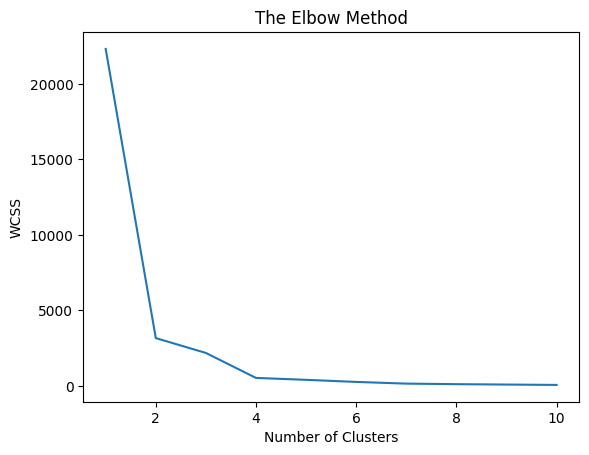

In [7]:
plt.plot(range(1, 11), wcss)

plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

print(y_kmeans)

[3 2 1 2 3 2 1 0 1 4 1 0 1 2 1 2 3 4 3 0]


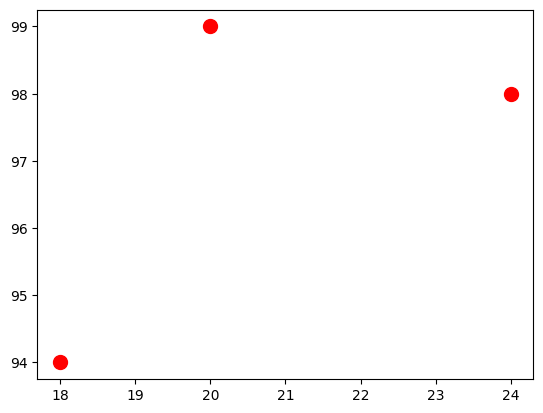

In [9]:
plt.scatter(
    X[y_kmeans == 0, 0],
    X[y_kmeans == 0, 1],
    s=100,
    c='red',
    label='Cluster 1'
)

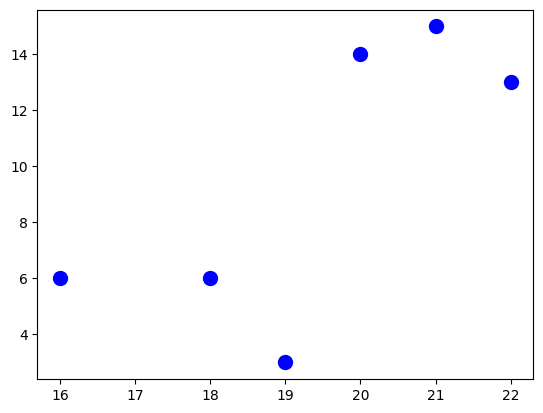

In [10]:
plt.scatter(
    X[y_kmeans == 1, 0],
    X[y_kmeans == 1, 1],
    s=100,
    c='blue',
    label='Cluster 2'
)

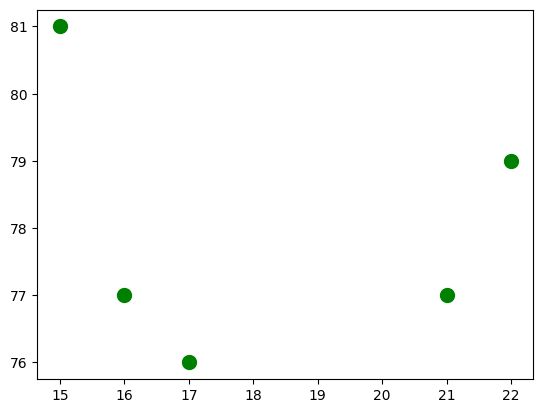

In [11]:
plt.scatter(
    X[y_kmeans == 2, 0],
    X[y_kmeans == 2, 1],
    s=100,
    c='green',
    label='Cluster 3'
)

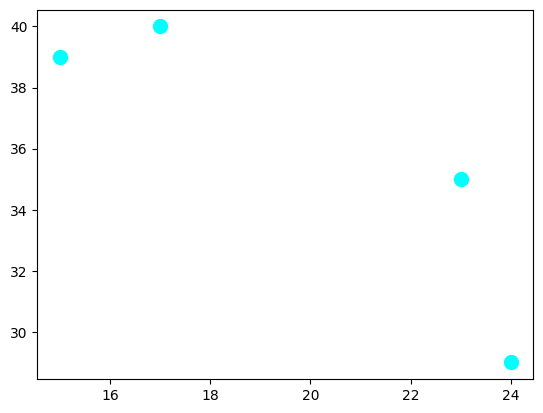

In [12]:
plt.scatter(
    X[y_kmeans == 3, 0],
    X[y_kmeans == 3, 1],
    s=100,
    c='cyan',
    label='Cluster 4'
)

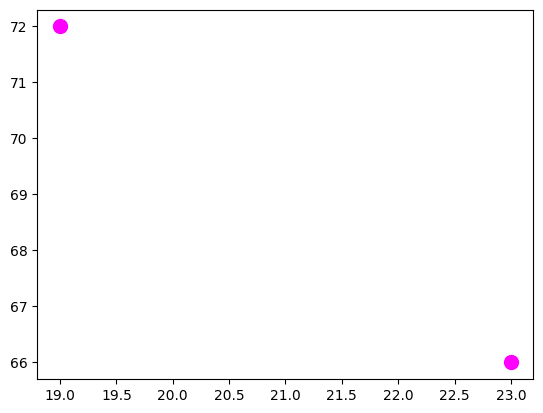

In [13]:
plt.scatter(
    X[y_kmeans == 4, 0],
    X[y_kmeans == 4, 1],
    s=100,
    c='magenta',
    label='Cluster 5'
)

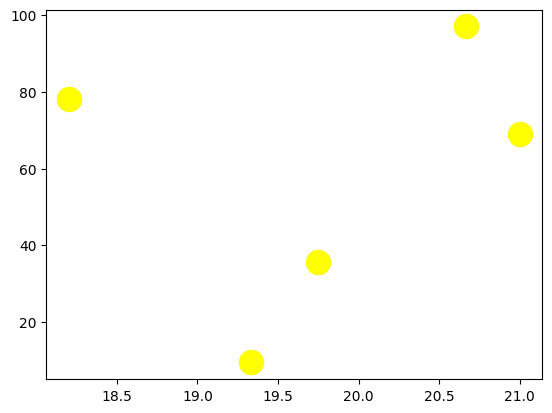

In [14]:
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='yellow',
    label='Centroids'
)

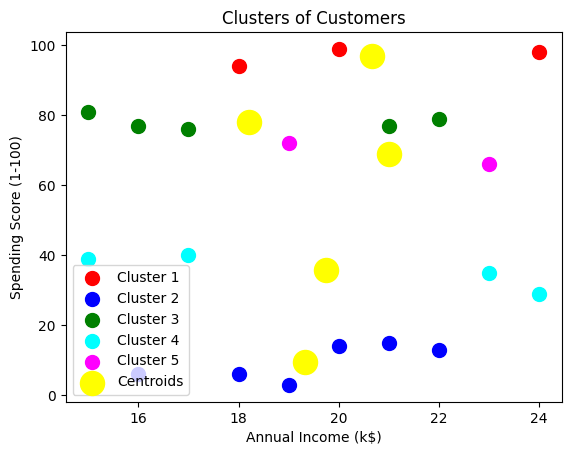

In [15]:
plt.scatter(
    X[y_kmeans == 0, 0],
    X[y_kmeans == 0, 1],
    s=100,
    c='red',
    label='Cluster 1'
)

plt.scatter(
    X[y_kmeans == 1, 0],
    X[y_kmeans == 1, 1],
    s=100,
    c='blue',
    label='Cluster 2'
)

plt.scatter(
    X[y_kmeans == 2, 0],
    X[y_kmeans == 2, 1],
    s=100,
    c='green',
    label='Cluster 3'
)

plt.scatter(
    X[y_kmeans == 3, 0],
    X[y_kmeans == 3, 1],
    s=100,
    c='cyan',
    label='Cluster 4'
)

plt.scatter(
    X[y_kmeans == 4, 0],
    X[y_kmeans == 4, 1],
    s=100,
    c='magenta',
    label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='yellow',
    label='Centroids'
)

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()

plt.show()

In [16]:
unique, counts = np.unique(y_kmeans, return_counts=True)

for i, count in enumerate(counts):
    print(f"Cluster {i+1}: {count} customers")

Cluster 1: 3 customers
Cluster 2: 6 customers
Cluster 3: 5 customers
Cluster 4: 4 customers
Cluster 5: 2 customers
